<table align="left">
<td vertical-align="bottom">
<a target="_blank" align="center" href="https://stepup.ai/train_data_augmentation_keras"><img height="32px" src="https://stepup.ai/favicon.png"/>Follow on stepup.ai</a>
</td>
<td>
 <a  target="_blank" href="https://colab.research.google.com/github/dufourpascal/stepupai/blob/master/tutorials/data_augmentation/train_data_augmentation_keras.ipynb"><img style="margin-bottom:10px" src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
</td>
<td>
<a target="_blank" href="https://github.com/dufourpascal/stepupai/blob/master/tutorials/data_augmentation/train_data_augmentation_keras.ipynb"><img style="margin-bottom:10px" class="invertable-logo" src="https://www.tensorflow.org/images/GitHub-Mark-32px.png"/>View source on GitHub</a>
</td>
<td>
<a href="https://drive.google.com/file/d/1-PBQVVUWhyQ_ctZFqMH02XihvmHOCjIe/view?usp=sharing" download><img class="invertable-logo" style="margin-bottom:10px" src="https://www.tensorflow.org/images/download_logo_32px.png"/>Download notebook</a>
</td>
</table>

# Training with Data Augmentation in Keras
In this tutorial, we are going to train a Cifar10 classifier from scratch and see how much benefit data augmentation can bring.
Follow along on the [blog post](https://stepup.ai/train_data_augmentation_keras) for descriptions and a detailed discussion!

# Setup

## Imports and Helper Functions
First we define the imports for tensorflow, keras and matplotlib.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

And we're going to define a helper function to plot the first few images in a dataset.

In [ ]:
def visualize_data(images, categories, class_names):
    fig = plt.figure(figsize=(14, 6))
    fig.patch.set_facecolor('white')
    for i in range(3 * 7):
        plt.subplot(3, 7, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.imshow(images[i])
        class_index = categories[i].argmax()
        plt.xlabel(class_names[class_index])
    plt.show()

## Load and Cifar10 Dataset
Now let's import the Cifar10 dataset and plot a few images along with their classes.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 259s 2us/step


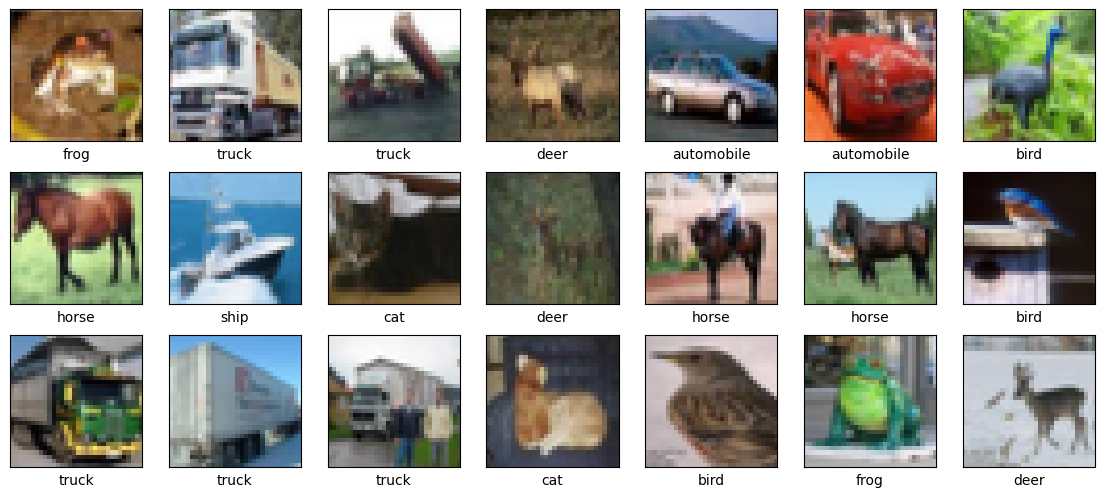

In [ ]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(class_names)

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train / 255.0
y_train = to_categorical(y_train, num_classes)

x_test = x_test / 255.0
y_test = to_categorical(y_test, num_classes)

visualize_data(x_train, y_train, class_names)

# Classifier Training

## Define the Model
We are going to create a function that creates a VGG style convolutional neural network classifier.

In [ ]:
def create_model():
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPool2D((2,2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same',))
    model.add(layers.MaxPool2D((2,2)))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',))
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same',))
    model.add(layers.MaxPool2D((2,2)))


    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

## Train without Data Augmentation
First we define the basic parameters for model training, such as batch size and number of epochs.
Then we instantiate the model and show the summary. Finally we train it with the unaugmented Cifar10 dataset.

In [ ]:
batch_size = 32
epochs = 16
m_no_aug = create_model()
m_no_aug.summary()

history_no_aug = m_no_aug.fit(
    x_train, y_train,
    epochs=epochs, batch_size=batch_size,
    validation_data=(x_test, y_test))

loss_no_aug, acc_no_aug = m_no_aug.evaluate(x_test,  y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 8ms/step - accuracy: 0.4395 - loss: 1.5282 - val_accuracy: 0.5747 - val_loss: 1.1887
Epoch 2/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6387 - loss: 1.0199 - val_accuracy: 0.6752 - val_loss: 0.9280
Epoch 3/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7142 - loss: 0.8111 - val_accuracy: 0.7093 - val_loss: 0.8126
Epoch 4/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7637 - loss: 0.6756 - val_accuracy: 0.7280 - val_loss: 0.7955
Epoch 5/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7962 - loss: 0.5844 - val_accuracy: 0.7568 - val_loss: 0.7097
Epoch 6/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8243 - loss: 0.4994 - val_accuracy: 0.7573 - val_loss: 0.7378
Epoch 7/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8499 - loss: 0.4275 - val_accuracy: 0.7380 - val_loss: 0.8329
Epoch 8/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8699 - loss: 0.3673 -

## Define Data Augmentation
Now it's time to set up our data augmentation pipeline.
First we define the augmentation parameters and then we instantiate the data generator.
We also plot a few augmented images to make sure that everything is ok

In [ ]:
width_shift = 3/32
height_shift = 3/32

datagen_h = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=width_shift,
    height_shift_range=height_shift,
)
datagen_h.fit(x_train)

## Train with Data Augmentation
Let's perform the training again, this time with data augmentation!

In [ ]:
m_aug_h = create_model()

history_aug_h = m_aug_h.fit(
    datagen_h.flow(x_train, y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(x_test, y_test))

loss_aug_h, acc_aug_h = m_aug_h.evaluate(x_test, y_test)

Epoch 1/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 24ms/step - accuracy: 0.3976 - loss: 1.6303 - val_accuracy: 0.5533 - val_loss: 1.2471
Epoch 2/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.5802 - loss: 1.1689 - val_accuracy: 0.6670 - val_loss: 0.9475
Epoch 3/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6577 - loss: 0.9672 - val_accuracy: 0.6904 - val_loss: 0.8740
Epoch 4/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6980 - loss: 0.8516 - val_accuracy: 0.7130 - val_loss: 0.8352
Epoch 5/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7262 - loss: 0.7840 - val_accuracy: 0.7283 - val_loss: 0.7988
Epoch 6/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7445 - loss: 0.7268 - val_accuracy: 0.7502 - val_loss: 0.7323
Epoch 7/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7602 - loss: 0.6903 - val_accuracy: 0.7642 - val_loss: 0.6973
Epoch 8/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7711 -

# Results
Let's compare the two runs in a single graph:

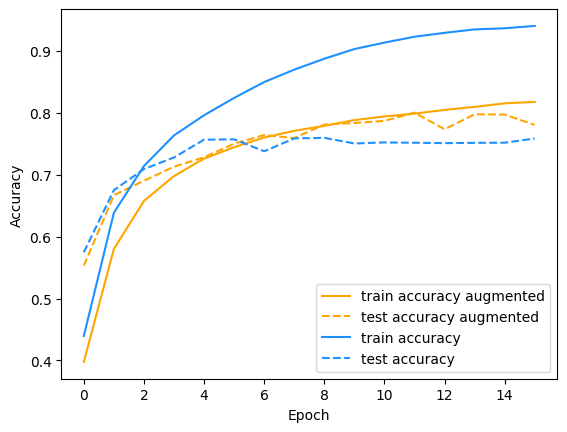

In [ ]:
fig = plt.figure()
fig.patch.set_facecolor('white')

plt.plot(history_aug_h.history['accuracy'],
         label='train accuracy augmented',
         c='orange', ls='-')
plt.plot(history_aug_h.history['val_accuracy'],
         label='test accuracy augmented',
         c='orange',ls='--')

plt.plot(history_no_aug.history['accuracy'],
         label='train accuracy',
         c='dodgerblue', ls='-')
plt.plot(history_no_aug.history['val_accuracy'],
         label='test accuracy',
         c='dodgerblue', ls='--')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

And lets also have a look at the loss curves:

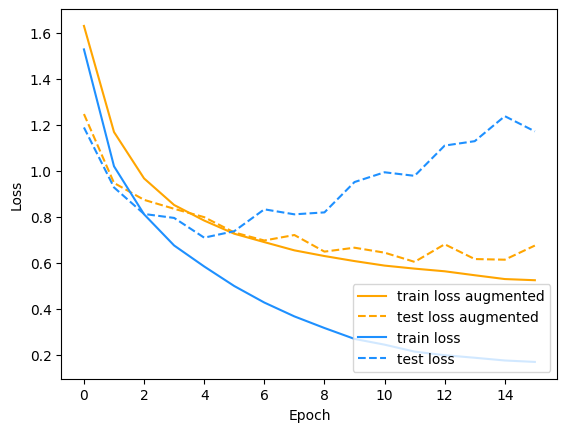

In [ ]:
fig = plt.figure()
fig.patch.set_facecolor('white')

plt.plot(history_aug_h.history['loss'],
         label='train loss augmented',
         c='orange', ls='-')
plt.plot(history_aug_h.history['val_loss'],
         label='test loss augmented',
         c='orange',ls='--')

plt.plot(history_no_aug.history['loss'],
         label='train loss',
         c='dodgerblue', ls='-')
plt.plot(history_no_aug.history['val_loss'],
         label='test loss',
         c='dodgerblue', ls='--')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='lower right')
plt.show()

In [ ]:
datagen_hv = ImageDataGenerator(
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=width_shift,
    height_shift_range=height_shift,
)
datagen_hv.fit(x_train)

In [ ]:
m_aug_hv = create_model()

history_aug_hv = m_aug_hv.fit(
    datagen_hv.flow(x_train, y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(x_test, y_test))

loss_aug_hv, acc_aug_hv = m_aug_hv.evaluate(x_test, y_test)

Epoch 1/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.3512 - loss: 1.7238 - val_accuracy: 0.4860 - val_loss: 1.3967
Epoch 2/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.4999 - loss: 1.3693 - val_accuracy: 0.5386 - val_loss: 1.2731
Epoch 3/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.5650 - loss: 1.2071 - val_accuracy: 0.6070 - val_loss: 1.1238
Epoch 4/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6075 - loss: 1.0988 - val_accuracy: 0.6127 - val_loss: 1.1173
Epoch 5/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6395 - loss: 1.0149 - val_accuracy: 0.6536 - val_loss: 0.9958
Epoch 6/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6556 - loss: 0.9646 - val_accuracy: 0.6574 - val_loss: 1.0050
Epoch 7/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.6707 - loss: 0.9208 - val_accuracy: 0.6792 - val_loss: 0.9083
Epoch 8/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6863 -

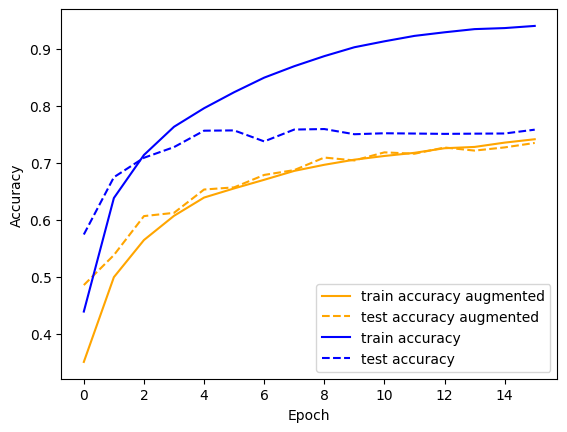

In [ ]:
fig = plt.figure()
fig.patch.set_facecolor('white')

plt.plot(history_aug_hv.history['accuracy'],
         label='train accuracy augmented', c='orange', ls='-')
plt.plot(history_aug_hv.history['val_accuracy'],
         label='test accuracy augmented', c='orange', ls='--')
plt.plot(history_no_aug.history['accuracy'],
         label='train accuracy', c='blue', ls='-')
plt.plot(history_no_aug.history['val_accuracy'],
         label='test accuracy', c='blue', ls='--')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

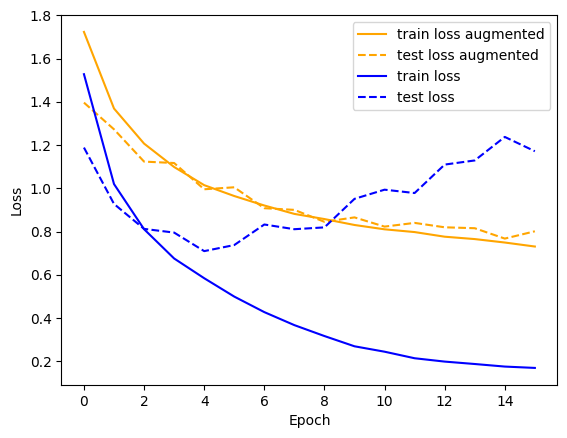

In [ ]:
fig = plt.figure()
fig.patch.set_facecolor('white')

plt.plot(history_aug_hv.history['loss'],
         label='train loss augmented', c='orange', ls='-')
plt.plot(history_aug_hv.history['val_loss'],
         label='test loss augmented', c='orange', ls='--')
plt.plot(history_no_aug.history['loss'],
         label='train loss', c='blue', ls='-')
plt.plot(history_no_aug.history['val_loss'],
         label='test loss', c='blue', ls='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
def create_deeper_model():
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu',
                            padding='same', input_shape=(32, 32, 3)))
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPool2D((2,2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPool2D((2,2)))

    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPool2D((2,2)))

    # Added layers
    model.add(layers.Dropout(0.2))
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPool2D((2,2)))
    model.add(layers.Dropout(0.2))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
m_deep_no_aug = create_deeper_model()
m_deep_no_aug.summary()

history_deep_no_aug = m_deep_no_aug.fit(
    x_train, y_train,
    epochs=epochs, batch_size=batch_size,
    validation_data=(x_test, y_test))

loss_deep_no_aug, acc_deep_no_aug = m_deep_no_aug.evaluate(x_test, y_test)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,304,746 (4.98 MB)

 Trainable params: 1,304,746 (4.98 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - accuracy: 0.3287 - loss: 1.7460 - val_accuracy: 0.4257 - val_loss: 1.5528
Epoch 2/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.5257 - loss: 1.3052 - val_accuracy: 0.6113 - val_loss: 1.0937
Epoch 3/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.6173 - loss: 1.0710 - val_accuracy: 0.6208 - val_loss: 1.0720
Epoch 4/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.6719 - loss: 0.9214 - val_accuracy: 0.6847 - val_loss: 0.8977
Epoch 5/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7099 - loss: 0.8244 - val_accuracy: 0.7160 - val_loss: 0.8268
Epoch 6/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7389 - loss: 0.7471 - val_accuracy: 0.7334 - val_loss: 0.7849
Epoch 7/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7565 - loss: 0.6927 - val_accuracy: 0.7317 - val_loss: 0.7842
Epoch 8/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7772 - loss: 

In [ ]:
m_deep_aug = create_deeper_model()

history_deep_aug = m_deep_aug.fit(
    datagen_h.flow(x_train, y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(x_test, y_test))

loss_deep_aug, acc_deep_aug = m_deep_aug.evaluate(x_test, y_test)

Epoch 1/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.2762 - loss: 1.9230 - val_accuracy: 0.4130 - val_loss: 1.6038
Epoch 2/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.4827 - loss: 1.4145 - val_accuracy: 0.5287 - val_loss: 1.3257
Epoch 3/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.5645 - loss: 1.2084 - val_accuracy: 0.6055 - val_loss: 1.1056
Epoch 4/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.6071 - loss: 1.0966 - val_accuracy: 0.6407 - val_loss: 1.0174
Epoch 5/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.6392 - loss: 1.0174 - val_accuracy: 0.6650 - val_loss: 0.9555
Epoch 6/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.6631 - loss: 0.9504 - val_accuracy: 0.6721 - val_loss: 0.9395
Epoch 7/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6838 - loss: 0.9010 - val_accuracy: 0.7064 - val_loss: 0.8606
Epoch 8/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7004 -

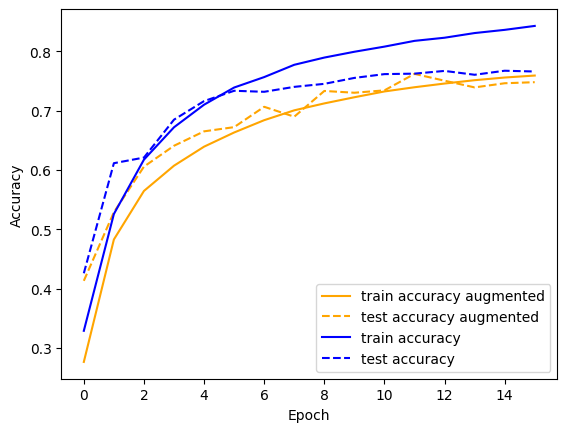

In [ ]:
fig = plt.figure()
fig.patch.set_facecolor('white')

plt.plot(history_deep_aug.history['accuracy'],
         label='train accuracy augmented', c='orange', ls='-')
plt.plot(history_deep_aug.history['val_accuracy'],
         label='test accuracy augmented', c='orange', ls='--')
plt.plot(history_deep_no_aug.history['accuracy'],
         label='train accuracy', c='blue', ls='-')
plt.plot(history_deep_no_aug.history['val_accuracy'],
         label='test accuracy', c='blue', ls='--')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()



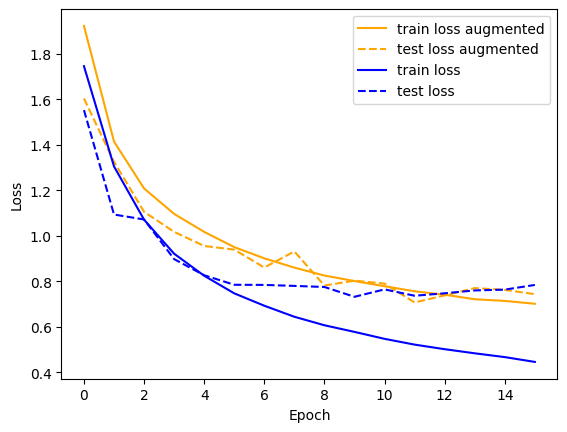

In [ ]:

fig = plt.figure()
fig.patch.set_facecolor('white')

plt.plot(history_deep_aug.history['loss'],
         label='train loss augmented', c='orange', ls='-')
plt.plot(history_deep_aug.history['val_loss'],
         label='test loss augmented', c='orange', ls='--')
plt.plot(history_deep_no_aug.history['loss'],
         label='train loss', c='blue', ls='-')
plt.plot(history_deep_no_aug.history['val_loss'],
         label='test loss', c='blue', ls='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
datagen_rot = ImageDataGenerator(
    horizontal_flip=True,
    width_shift_range=width_shift,
    height_shift_range=height_shift,
    rotation_range=15,
)
datagen_rot.fit(x_train)

In [ ]:
m_deep_rot = create_deeper_model()

history_deep_rot = m_deep_rot.fit(
    datagen_rot.flow(x_train, y_train, batch_size=batch_size),
    epochs=epochs,
    validation_data=(x_test, y_test))

loss_deep_rot, acc_deep_rot = m_deep_rot.evaluate(x_test, y_test)

Epoch 1/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 49s 27ms/step - accuracy: 0.3311 - loss: 1.7900 - val_accuracy: 0.4609 - val_loss: 1.4927
Epoch 2/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.4988 - loss: 1.3718 - val_accuracy: 0.5712 - val_loss: 1.2062
Epoch 3/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.5710 - loss: 1.1955 - val_accuracy: 0.6004 - val_loss: 1.1436
Epoch 4/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6138 - loss: 1.0947 - val_accuracy: 0.6547 - val_loss: 0.9832
Epoch 5/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.6389 - loss: 1.0166 - val_accuracy: 0.6682 - val_loss: 0.9396
Epoch 6/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6601 - loss: 0.9648 - val_accuracy: 0.6853 - val_loss: 0.9013
Epoch 7/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6774 - loss: 0.9188 - val_accuracy: 0.7027 - val_loss: 0.8465
Epoch 8/16
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6924 -

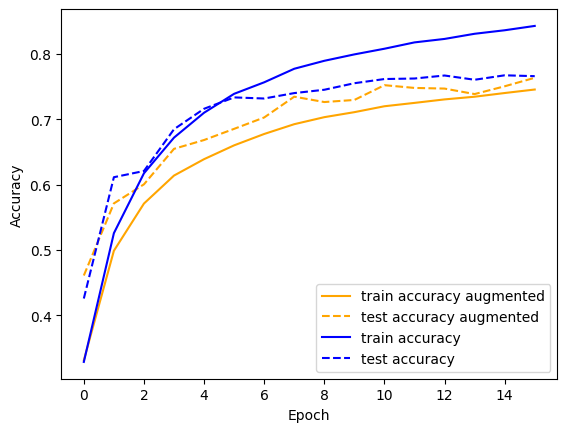

In [ ]:

fig = plt.figure()
fig.patch.set_facecolor('white')

plt.plot(history_deep_rot.history['accuracy'],
         label='train accuracy augmented', c='orange', ls='-')
plt.plot(history_deep_rot.history['val_accuracy'],
         label='test accuracy augmented', c='orange', ls='--')
plt.plot(history_deep_no_aug.history['accuracy'],
         label='train accuracy', c='blue', ls='-')
plt.plot(history_deep_no_aug.history['val_accuracy'],
         label='test accuracy', c='blue', ls='--')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

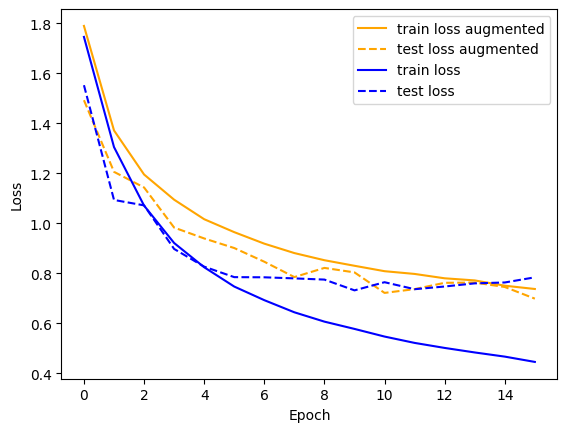

In [ ]:
fig = plt.figure()
fig.patch.set_facecolor('white')

plt.plot(history_deep_rot.history['loss'],
         label='train loss augmented', c='orange', ls='-')
plt.plot(history_deep_rot.history['val_loss'],
         label='test loss augmented', c='orange', ls='--')
plt.plot(history_deep_no_aug.history['loss'],
         label='train loss', c='blue', ls='-')
plt.plot(history_deep_no_aug.history['val_loss'],
         label='test loss', c='blue', ls='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Final summary of all configurations
print("=" * 65)
print("CONFIGURATION COMPARISON SUMMARY")
print("=" * 65)
print(f"{'Config':<45} {'Test Acc':>10}")
print("-" * 65)
print(f"{'1 - Original arch, no augmentation':<45} {acc_no_aug:>10.4f}")
print(f"{'2 - Original arch, horizontal flip':<45} {acc_aug_h:>10.4f}")
print(f"{'3 - Original arch, H+V flip':<45} {acc_aug_hv:>10.4f}")
print(f"{'4 - Deeper arch, no augmentation':<45} {acc_deep_no_aug:>10.4f}")
print(f"{'5 - Deeper arch, horizontal flip':<45} {acc_deep_aug:>10.4f}")
print(f"{'6 - Deeper arch, H flip + rotation':<45} {acc_deep_rot:>10.4f}")
print("=" * 65)

all_acc = {
    '1 - Original arch, no augmentation': acc_no_aug,
    '2 - Original arch, horizontal flip': acc_aug_h,
    '3 - Original arch, H+V flip': acc_aug_hv,
    '4 - Deeper arch, no augmentation': acc_deep_no_aug,
    '5 - Deeper arch, horizontal flip': acc_deep_aug,
    '6 - Deeper arch, H flip + rotation': acc_deep_rot,
}
champion = max(all_acc, key=all_acc.get)
print(f"\nChampion: Config {champion} ({all_acc[champion]:.4f})")

CONFIGURATION COMPARISON SUMMARY
Config                                          Test Acc
-----------------------------------------------------------------
1 - Original arch, no augmentation                0.7586
2 - Original arch, horizontal flip                0.7806
3 - Original arch, H+V flip                       0.7353
4 - Deeper arch, no augmentation                  0.7659
5 - Deeper arch, horizontal flip                  0.7479
6 - Deeper arch, H flip + rotation                0.7634

Champion: Config 2 - Original arch, horizontal flip (0.7806)


Head over to the [blog post](https://stepup.ai/train_data_augmentation_keras) for a detailed discussion!